<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C17/C17_Script01_EstadisticaInferencial_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejemplos de Aplicación

In [5]:
# Carguemos módulos
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplito 1

In [6]:
# Cálculo de probabilidad de una distribución normal
# Enunciado: La resistencia de comprensión de una viga de acero sigue una
# distribución normal, con media de 500 MPa y desviación estandar sigma de 20 MPa.
# ¿Cuál es la probabilidad de que una viga seleccionada al azar tenga una resistencia
# menos a 480 MPa?

mu = 500
sigma = 20
x = 480

# Calculo teórico
z_score = (x - mu)/sigma
print("Z score:", z_score)

# Interpretaciónd e Z:
# z = 0: Valor igual a la media
# z = 1: Un valor que está 1 desviación estandar por encima de la media
# z = -1: Un valor que está 1 desviación estandar por debajo de la media

# Uso de la función de distribución acumulada: CDF devuelve probabilidades acumuladas (área a la izquierda)
probabilidad = stats.norm.cdf(z_score) # P[Z < -1.0]
# phi(z) = P[Z < z_score]
print("Probabilidad de que al seleccionar una viga al azar, esta tenga una resistencia menor a 480 MPa ", probabilidad)

# Interpretación de la probabilidad obtenida:
# Aproximadamente 1 de cada 6 vigas (15.87%) tendrá una resistencia menor a 480 MPa
# El 84.13% de las vigas cumplirán o superarán los 480 MPa

Z score: -1.0
Probabilidad de que al seleccionar una viga al azar, esta tenga una resistencia menor a 480 MPa  0.15865525393145707


# Ejemplito 2

In [ ]:
# Intervalo de confianza
# Enunciado: Se mide el diámetro de 50 rodamientos. La media muestral es de 5.02 cm,
# se sabe por histórico que la desviación estándar poblacional es de 0.1 cm.
# Calcular el IC al 95%

En vista que conocemos $\sigma$

$$
IC = \bar{x} \pm Z_{1 - \alpha /2} \frac{\sigma}{\sqrt{n}}
$$

In [7]:
# Tamaño de la muestra
n = 50

# Mejor estimación puntual de la media (mu: media poblacional)
x_bar = 5.02

confianza = 0.95
# Z_{1 - alpha/2}: Valor crítico de la distribución normal
# Para un 95% de confianza: alpha = 0.05 → alpha/2 = 0.025
# Z_{0.95} = 1.96

# Variabilidad poblacional
sigma = 0.1

# sqrt(n) : factor de reduccion del error estandar
# sigma/sqrt(n) : error estandar de la media

intervalo = stats.norm.interval(confidence = confianza, loc=x_bar, scale=sigma/np.sqrt(n))
print("IC al 95%: ", intervalo)

# Interpretacion del 95% de confianza
# NO SIGNIFICA : hay un 95% de probabilidad de que mu (media poblacional) este entre [4.99, 5.04]
# Interpretacion correcta : Si repitieramos el muestreo muchas veces, el 95% de los intervalos construidos contendrian
# el verdadero mu.

IC al 95%:  (np.float64(4.992281923513006), np.float64(5.047718076486993))


¿Porqué podemos usar Z? → Por el teorema del límite central

Si $X_1 , X_2, X_3 ,  \cdots , X_n$ son variables aleatorias i.i.d con media $\mu$ y varianza $\sigma^2$, entonces cuando $n$ se haga demasiado grande

$$
Z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}} ≈ N(0,1)
$$


# Ejemplito 3

In [ ]:
# Enunciado : Se mide el diametro de 50 rodamientos. La media muestral es 5.02 cm.
# La desviacion estandar muestral calculada es s = 0.12 cm .
# Calcular el intervalo de confianza al 95%

Cambios fundamentales en el analisis

* Antes ($\sigma$ conocida)
$$
IC = \bar{x} \pm Z_{1 - \alpha /2} \frac{\sigma}{\sqrt{n}}
$$

* Ahora ($\sigma$ desconocida)

$$
IC = \bar{x} \pm t_{n-1, 1-\alpha/2} \frac{s}{\sqrt{n}}
$$

Razon teorica del cambio : Cuando estimamos $\sigma$ con $s$, introducimos incertidumbre adicional. El autor de la $student$ (Gosset) demostró que :

Si $X_1, X_2, X_3, \cdots, X_n ≈ N(0,1)$ con $\sigma$ desconocida

$$t = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}} \approx t_{n-1}$$

In [8]:
x_bar = 5.02
s = 0.12
n = 50
confianza = 0.95

# Determinar alpha y t_critico
alpha = 1-confianza
df = n-1
t_critico = stats.t.ppf(1-alpha/2 , df)
print("t_critico : ", t_critico)

# Para comparacion : Z para el mismo nivel
z_critico = stats.norm.ppf(1-alpha/2)
print("z_critico : ", z_critico )

# Calculamos el error estandar
error_estandar = s/np.sqrt(n)

# margen del error
margen_error = t_critico * error_estandar

# Calculamos los limites del IC
limite_inferior = x_bar - margen_error
limite_superior = x_bar + margen_error
print("IC al 95% : [ ", limite_inferior , ", ", limite_superior , "]")

t_critico :  2.0095752371292397
z_critico :  1.959963984540054
IC al 95% : [  4.985896377340512 ,  5.054103622659487 ]


# Ejemplito 4

In [28]:
# Simulación de la distribución muestral (Dados)
# Enunciado: Simulemos el lanzamiento de un dado honesto. Muestre que al promediar
# 30 lanzamientos repetidamente, la distribución de esos promedios se vuelve normal (TLC).

# Análisis: La distribución original es uniforme discreta. Al tomar medias de muestras (n = 30),
# la distribución muestral tiende a la normalidad.

simulaciones = 1000000
n_lanzamientos = 30
medias = [np.mean(np.random.randint(1,7,n_lanzamientos)) for _ in range(simulaciones)]

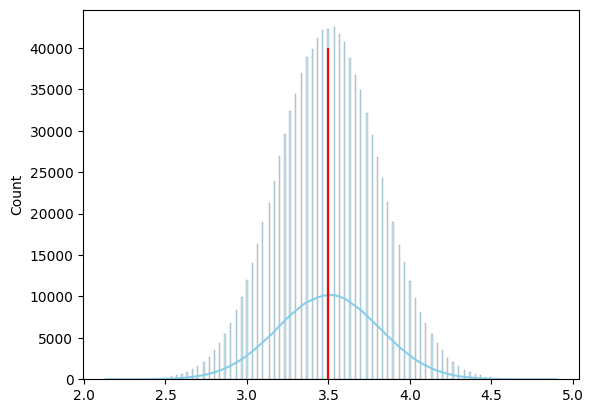

In [29]:
# Histograma de esas medias calculadas
sns.histplot(medias, kde=True, color = "skyblue")
plt.vlines(x = 3.5,ymin= 0, ymax = 40000, color = "red")
plt.show()

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

def plot_distribution_muestral(simulaciones, n_lanzamientos):
    """
    Genera un histograma de la distribución muestral de medias de lanzamientos de un dado.

    Args:
        simulaciones: Número de simulaciones a realizar
        n_lanzamientos: Número de lanzamientos por simulación
    """
    # Generar las simulaciones
    medias = [np.mean(np.random.randint(1, 7, n_lanzamientos)) for _ in range(simulaciones)]

    # Crear la figura
    fig, ax = plt.subplots(figsize=(10, 6))

    # Crear el histograma
    sns.histplot(medias, kde=True, color='skyblue', ax=ax, bins=30)

    # Personalizar el gráfico
    ax.set_title(f'Distribución Muestral (n={n_lanzamientos}, simulaciones={simulaciones}) de un Dado', fontsize=14)
    ax.set_xlabel('Media muestral', fontsize=12)
    ax.set_ylabel('Frecuencia', fontsize=12)
    ax.grid(True, alpha=0.3)

    # Agregar línea vertical en la media teórica (3.5)
    ax.axvline(x=3.5, color='red', linestyle='--', linewidth=2, label='Media teórica (3.5)')

    # Agregar estadísticas en el gráfico
    ax.text(0.02, 0.98, f'Media: {np.mean(medias):.3f}\nDesv. estándar: {np.std(medias):.3f}',
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.legend()

    return fig

# Crear la interfaz Gradio
with gr.Blocks(title="Simulación de Distribución Muestral") as demo:
    gr.Markdown("""
    # 📊 Simulación de Distribución Muestral de un Dado

    Esta aplicación simula la distribución muestral de las medias de lanzamientos de un dado.
    Ajusta los parámetros usando los sliders y observa cómo cambia la distribución.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            simulaciones_slider = gr.Slider(
                minimum=100,
                maximum=5000,
                value=1000,
                step=100,
                label="Número de simulaciones",
                info="Cantidad de muestras a generar"
            )

            n_lanzamientos_slider = gr.Slider(
                minimum=10,
                maximum=200,
                value=30,
                step=10,
                label="Tamaño de muestra (n)",
                info="Número de lanzamientos por simulación"
            )

            generar_btn = gr.Button("Generar gráfico", variant="primary")

            gr.Markdown("""
            ### 📝 Notas:
            - Cada simulación genera `n` lanzamientos de un dado justo (valores 1-6)
            - Se calcula la media de cada muestra
            - La línea roja punteada muestra la media teórica (3.5)
            - El histograma muestra la distribución de todas las medias calculadas
            """)

        with gr.Column(scale=2):
            plot_output = gr.Plot(label="Distribución Muestral")

    # Conectar los componentes
    generar_btn.click(
        fn=plot_distribution_muestral,
        inputs=[simulaciones_slider, n_lanzamientos_slider],
        outputs=plot_output
    )

    # También actualizar automáticamente al cambiar los sliders
    simulaciones_slider.change(
        fn=plot_distribution_muestral,
        inputs=[simulaciones_slider, n_lanzamientos_slider],
        outputs=plot_output
    )

    n_lanzamientos_slider.change(
        fn=plot_distribution_muestral,
        inputs=[simulaciones_slider, n_lanzamientos_slider],
        outputs=plot_output
    )

# Para ejecutar la aplicación
if __name__ == "__main__":
    demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://86b30e6208f006dc12.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Ejemplito 5


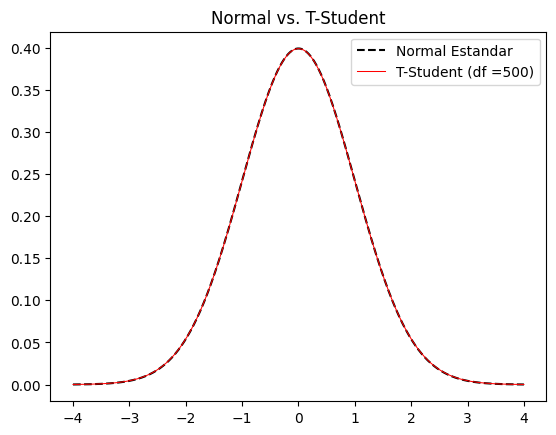

In [35]:
# Grafiquemos y comparemos una distribucion normal con una T-Student

x = np.linspace(-4,4, 10000)
grados_libertad = 500
plt.plot(x, stats.norm.pdf(x), label = "Normal Estandar", color = "black", linestyle = "--")
plt.plot(x , stats.t.pdf(x, df = grados_libertad), label = "T-Student (df =" + str(grados_libertad) +   ")" , color = "red", linewidth=0.75)
plt.legend()
plt.title("Normal vs. T-Student")
plt.show()

# Ejemplito 6

In [ ]:
# Prueba T para una muestra (Control de calidad)

# Enunciado: Una planta química debe mantener un pH de 7.0. Se toman 15 muestras y se obtiene una
# media de 7.2 con desviación estándar muestral de 0.3. ¿Hay evidencia significativa (alpha = 0.05) de que
# el proceso está fuera de control?

Analisis : Aplicacion de Prueba de Hipotesis

$$
H_{0} : \mu = 7.0
$$

$$
H_{1} : \mu \neq 7.0
$$

Usamos T-test de una muestra

In [40]:
# Simulemos los datos
data_ph = np.random.normal(7.2, 0.3, 15)

t_stat , p_value = stats.ttest_1samp(data_ph, popmean= 7.0)

print("p_value: ", p_value)
print("Rechazar H0 (Proceso Descalibrado)" if p_value < 0.05 else "No rechazar H0")

p_value:  0.033358243456939815
Rechazar H0 (Proceso Descalibrado)


# Ejemplito 7

In [ ]:
# Prueba T para dos muestras independientes (Comparación de modelos)

# Enunciado: Un ingeniero compara los tiempos de compilación (segundos) de dos servidores.
# "Servidor A"
# "Servidor B"

**Formulación de Hipótesis**

* $H_0$: (Status Quo)
$$
H_0: \mu{A} = \mu_{B}
$$

* $H_{1}$: Lo que queremos probar

  * Opción 1 (Dos colas): Detecta cualquier diferencia

    $$
    H_1: \mu_{A} \neq \mu_{B}
    $$

  * Opción 2 (Una cola): Detecta una dirección especifica

    $$
    H_1: \mu_{A} > \mu_{B}  \\;\\;\text{o} \\;\\;  H_1: \mu_{A} < \mu_{B}
    $$

In [45]:
# Generemos datos
servidor_a = np.random.normal(45,2,20)
servidor_b = np.random.normal(43,2,20)

#
t_stat , p_value = stats.ttest_ind(servidor_a, servidor_b)
print("p_value: ", p_value)

p_value:  0.0010358103020557188
